In [22]:
import numpy as np
import altair as alt
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
portuguese = pd.read_excel("student_performance/student_performance.xlsx", sheet_name="portuguese", skiprows=2)
math = pd.read_excel("student_performance/student_performance.xlsx", sheet_name="math", skiprows=1)
data_frames = [portuguese, math]
for df in data_frames:
    df.drop(columns=["Unnamed: 0", "Unnamed: 1"], inplace=True, errors="ignore")
    df.drop_duplicates(inplace=True)
    for col in df.columns:
        if df[col].dtype == "str" :
            df[col] = df[col].astype("category")

In [24]:
math.info()

<class 'pandas.DataFrame'>
Index: 395 entries, 0 to 434
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          395 non-null    int64   
 1   school      395 non-null    category
 2   sex         395 non-null    category
 3   age         391 non-null    float64 
 4   address     394 non-null    category
 5   famsize     393 non-null    category
 6   Pstatus     390 non-null    category
 7   Medu        390 non-null    float64 
 8   Fedu        391 non-null    float64 
 9   Mjob        392 non-null    category
 10  Fjob        392 non-null    category
 11  reason      390 non-null    category
 12  guardian    392 non-null    category
 13  traveltime  392 non-null    float64 
 14  studytime   392 non-null    float64 
 15  failures    391 non-null    float64 
 16  schoolsup   392 non-null    category
 17  famsup      392 non-null    category
 18  paid        392 non-null    category
 19  activities  389 non-null

In [25]:
def data_analysis(df: pd.DataFrame) -> None:
    print("Dataframe shape:", df.shape)
    print("\nDataframe info:")
    print(df.info())
    print("\nDataframe description:")
    print(df.describe())
    print("\nMissing values:")
    print(df.isnull().sum())
    msno.matrix(df)
    plt.show()

Dataframe shape: (649, 34)

Dataframe info:
<class 'pandas.DataFrame'>
Index: 649 entries, 0 to 713
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          649 non-null    int64   
 1   school      649 non-null    category
 2   sex         649 non-null    category
 3   age         645 non-null    float64 
 4   address     647 non-null    category
 5   famsize     644 non-null    category
 6   Pstatus     644 non-null    category
 7   Medu        644 non-null    float64 
 8   Fedu        644 non-null    float64 
 9   Mjob        648 non-null    category
 10  Fjob        646 non-null    category
 11  reason      645 non-null    category
 12  guardian    646 non-null    category
 13  traveltime  647 non-null    float64 
 14  studytime   646 non-null    float64 
 15  failures    646 non-null    float64 
 16  schoolsup   647 non-null    category
 17  famsup      647 non-null    category
 18  paid        645 non-nu

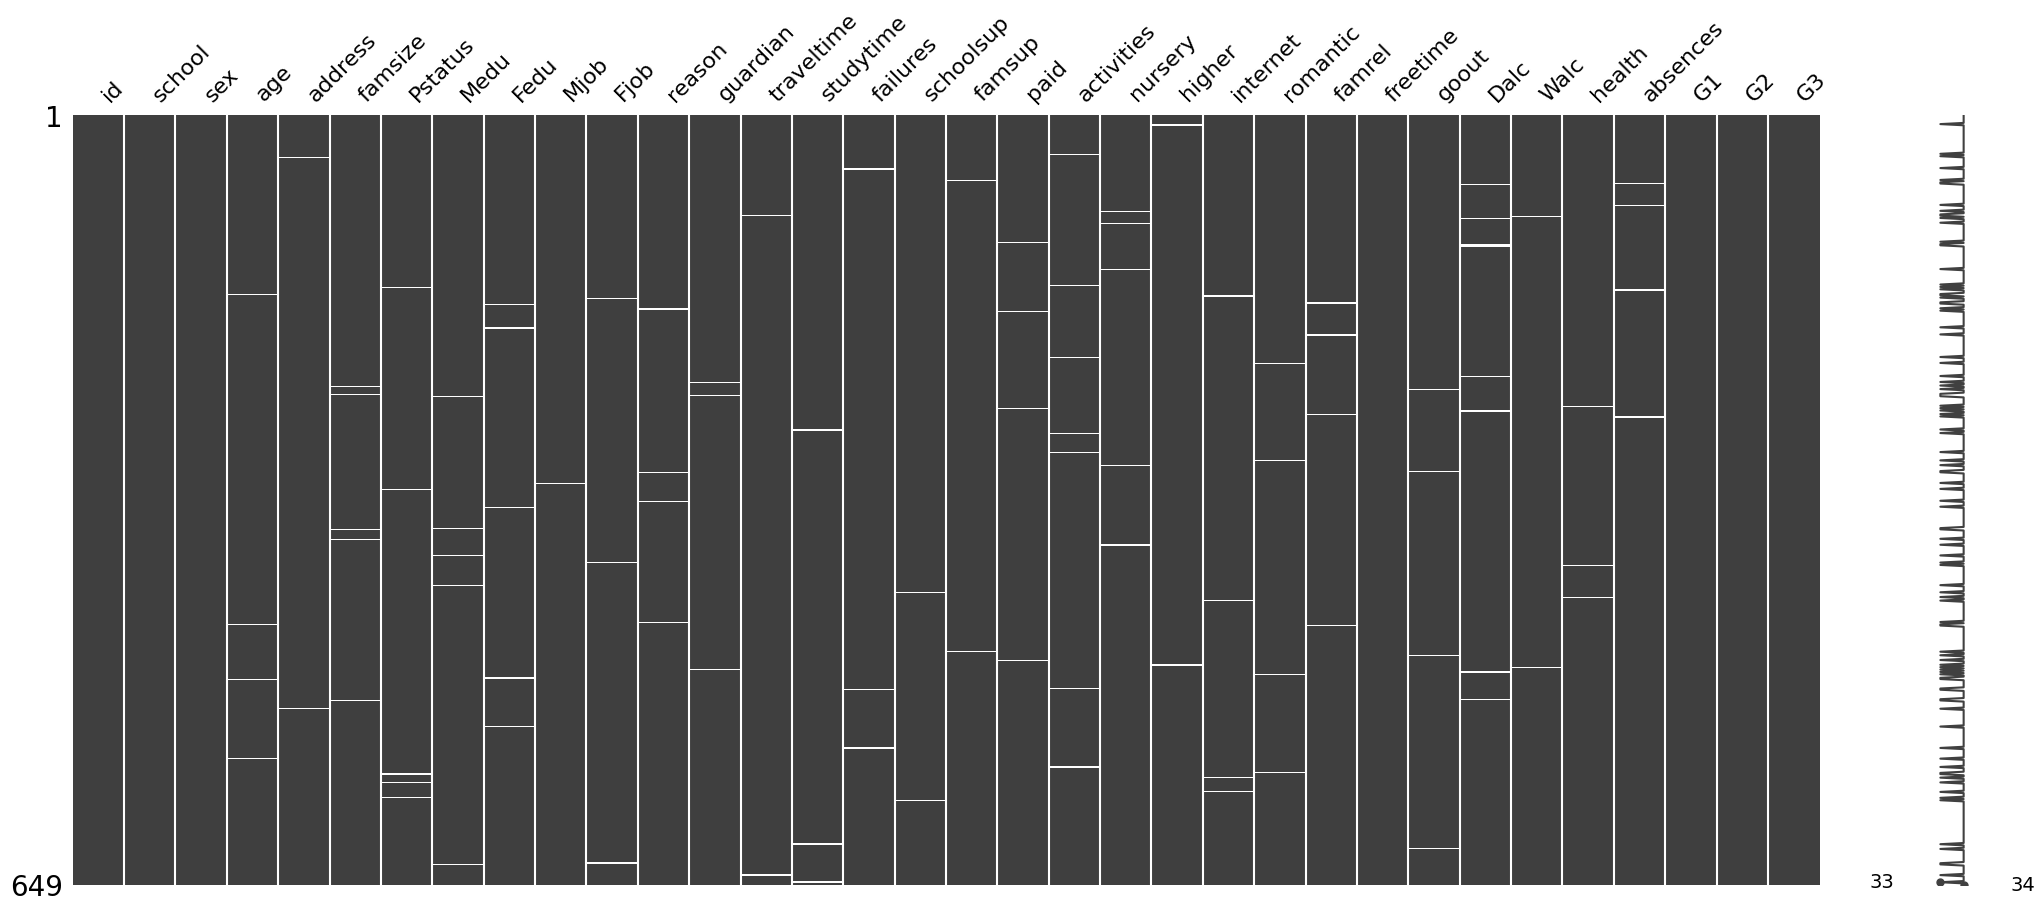

In [26]:
data_analysis(portuguese)

Dataframe shape: (395, 34)

Dataframe info:
<class 'pandas.DataFrame'>
Index: 395 entries, 0 to 434
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          395 non-null    int64   
 1   school      395 non-null    category
 2   sex         395 non-null    category
 3   age         391 non-null    float64 
 4   address     394 non-null    category
 5   famsize     393 non-null    category
 6   Pstatus     390 non-null    category
 7   Medu        390 non-null    float64 
 8   Fedu        391 non-null    float64 
 9   Mjob        392 non-null    category
 10  Fjob        392 non-null    category
 11  reason      390 non-null    category
 12  guardian    392 non-null    category
 13  traveltime  392 non-null    float64 
 14  studytime   392 non-null    float64 
 15  failures    391 non-null    float64 
 16  schoolsup   392 non-null    category
 17  famsup      392 non-null    category
 18  paid        392 non-nu

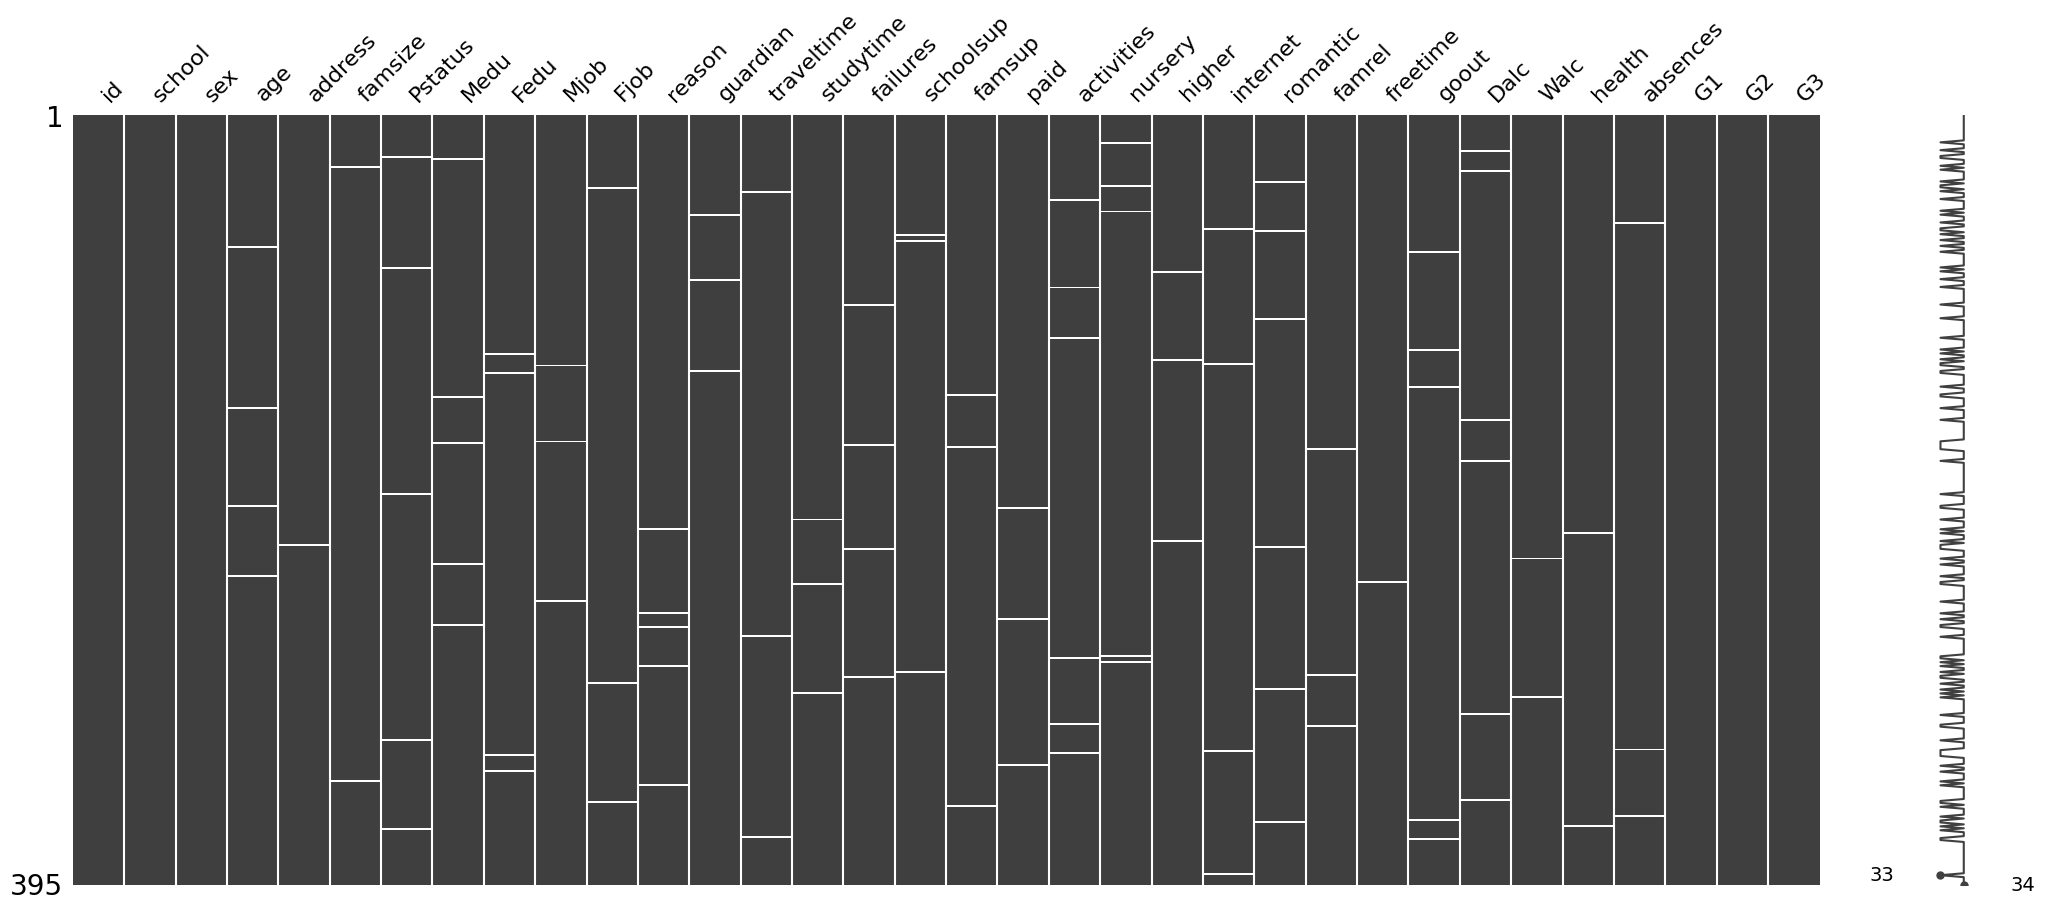

In [27]:
data_analysis(math)

In [28]:
def exploratory_data_analysis(df: pd.DataFrame) -> None:
    df = df.copy()
    # fill na 
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    # merge target variables and parent education into single columns for easier plotting
    df["target"] = df[["G1", "G2", "G3"]].mean(axis=1)

    # drop some columns for better visualization
    plot_df = df.drop(columns=["id","G1", "G2", "G3", "Medu", "Fedu", "Dalc", "Walc", "famrel", "goout"], errors="ignore")
    sns.pairplot(plot_df, hue="target")
    
    # Select all categorical columns
    cat_cols = df.select_dtypes(include=['category']).columns

    # Plot the first 9 categorical features as an example
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols[:9]):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(8, 5))
    sns.histplot(df['G3'], bins=20, kde=True, color='#2c7fb8')

    # Add a line for the mean
    mean_g3 = df['G3'].mean()
    plt.axvline(mean_g3, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_g3:.2f}')

    plt.title('Distribution of Final Grade (G3)')
    plt.xlabel('Final Grade (G3)')
    plt.ylabel('Number of Students')
    plt.legend()
    plt.show()

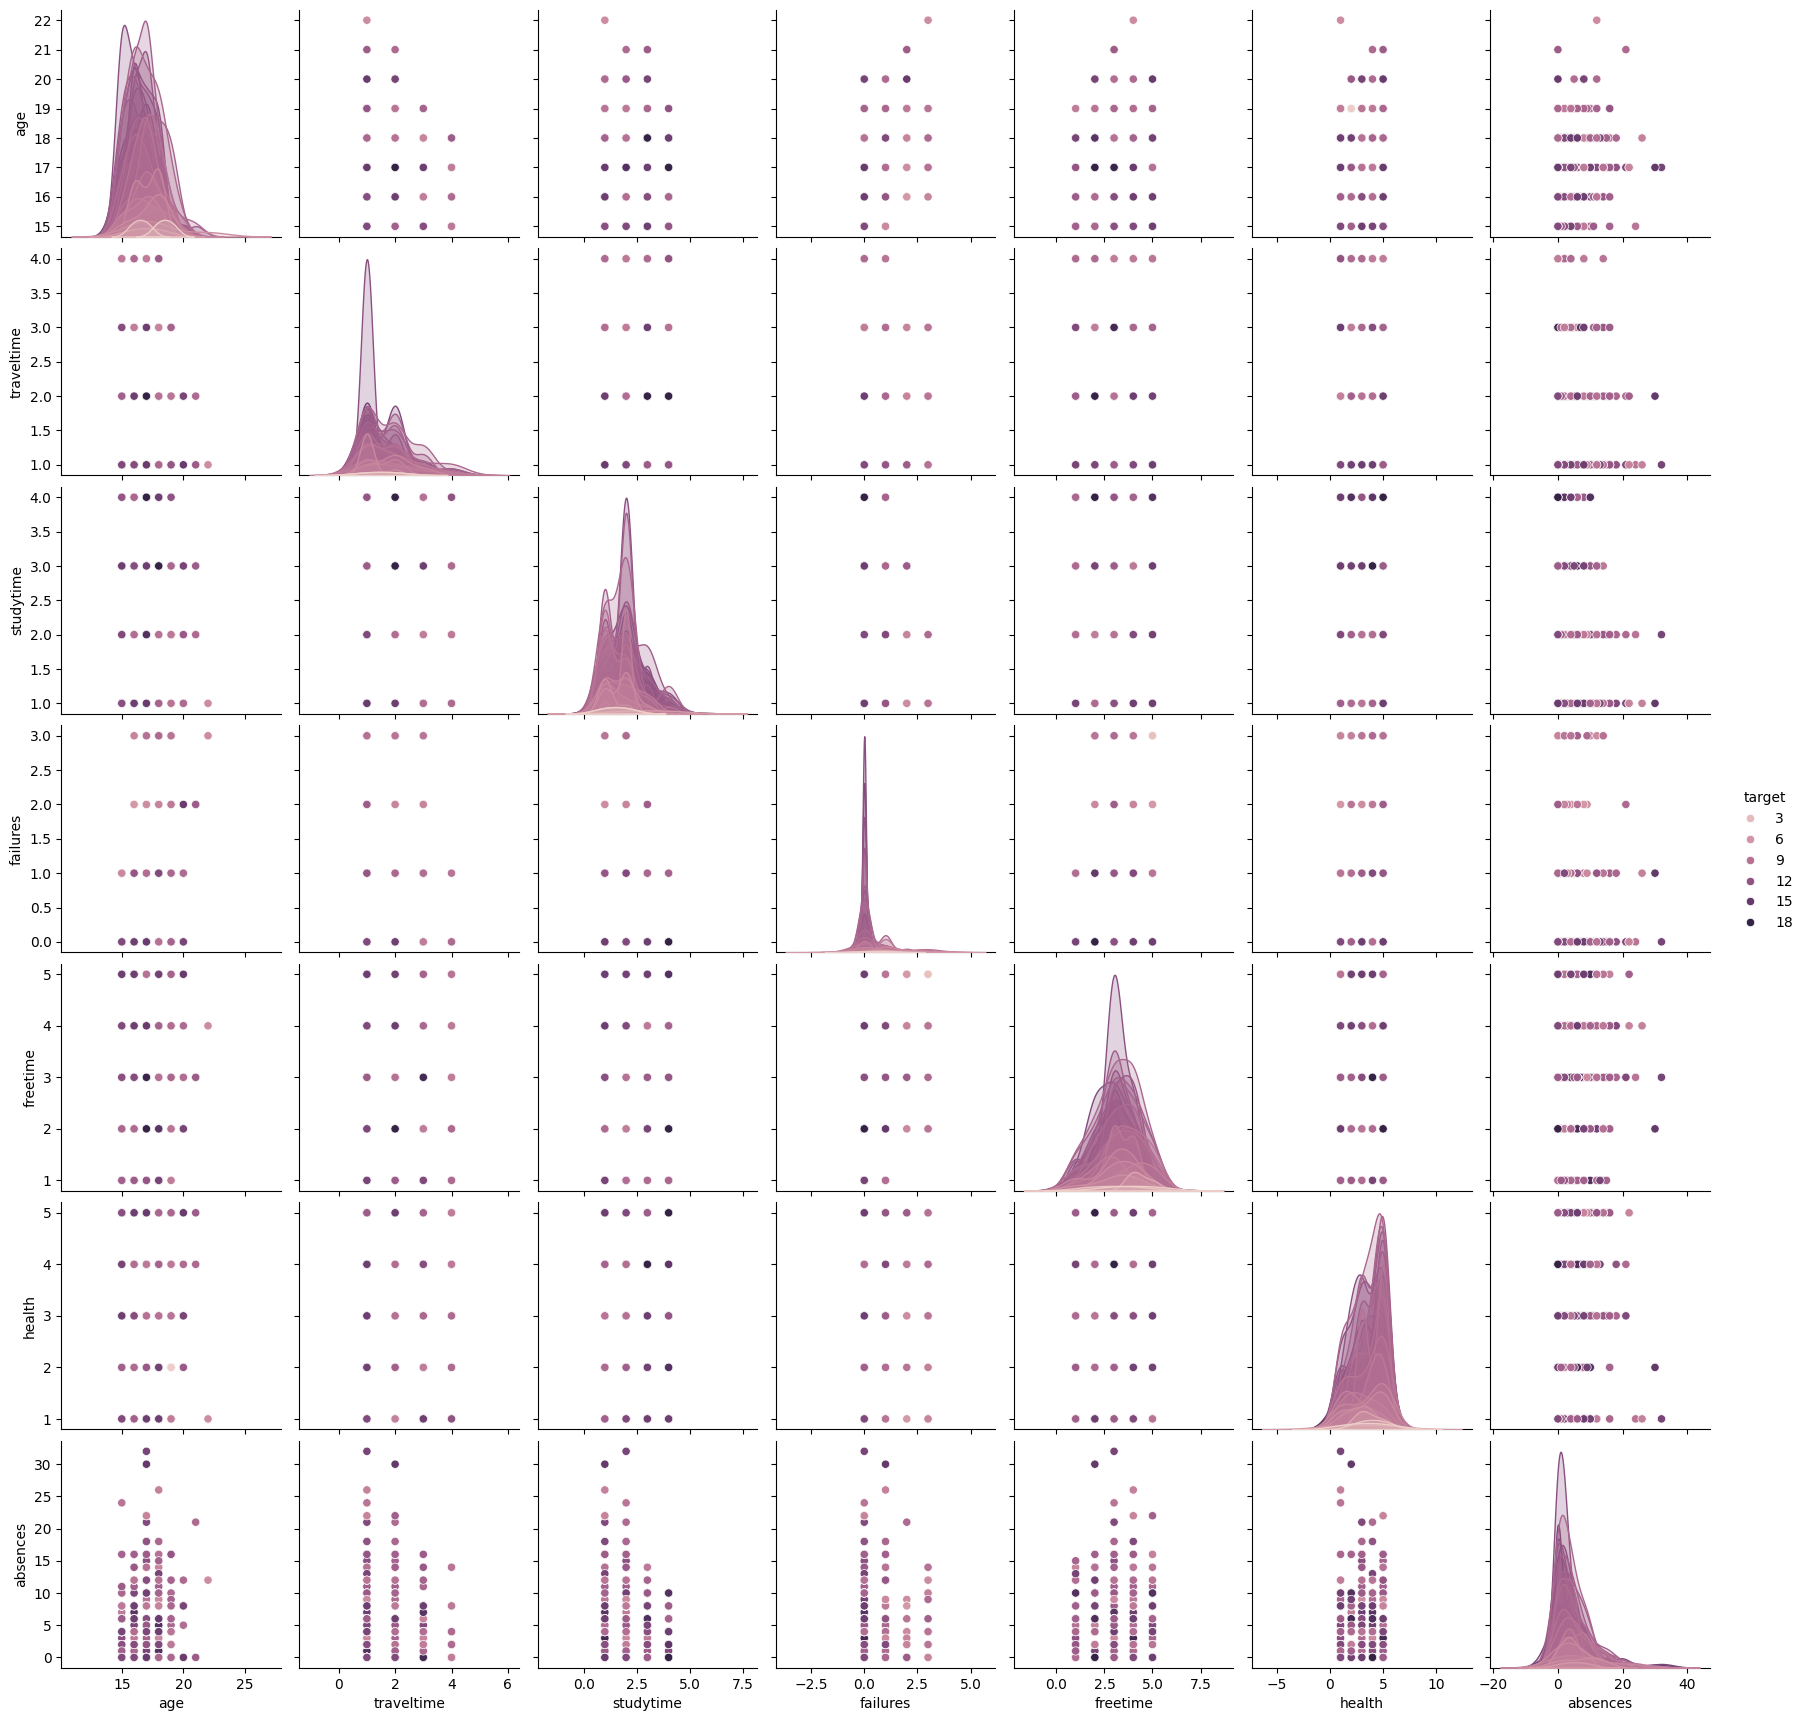

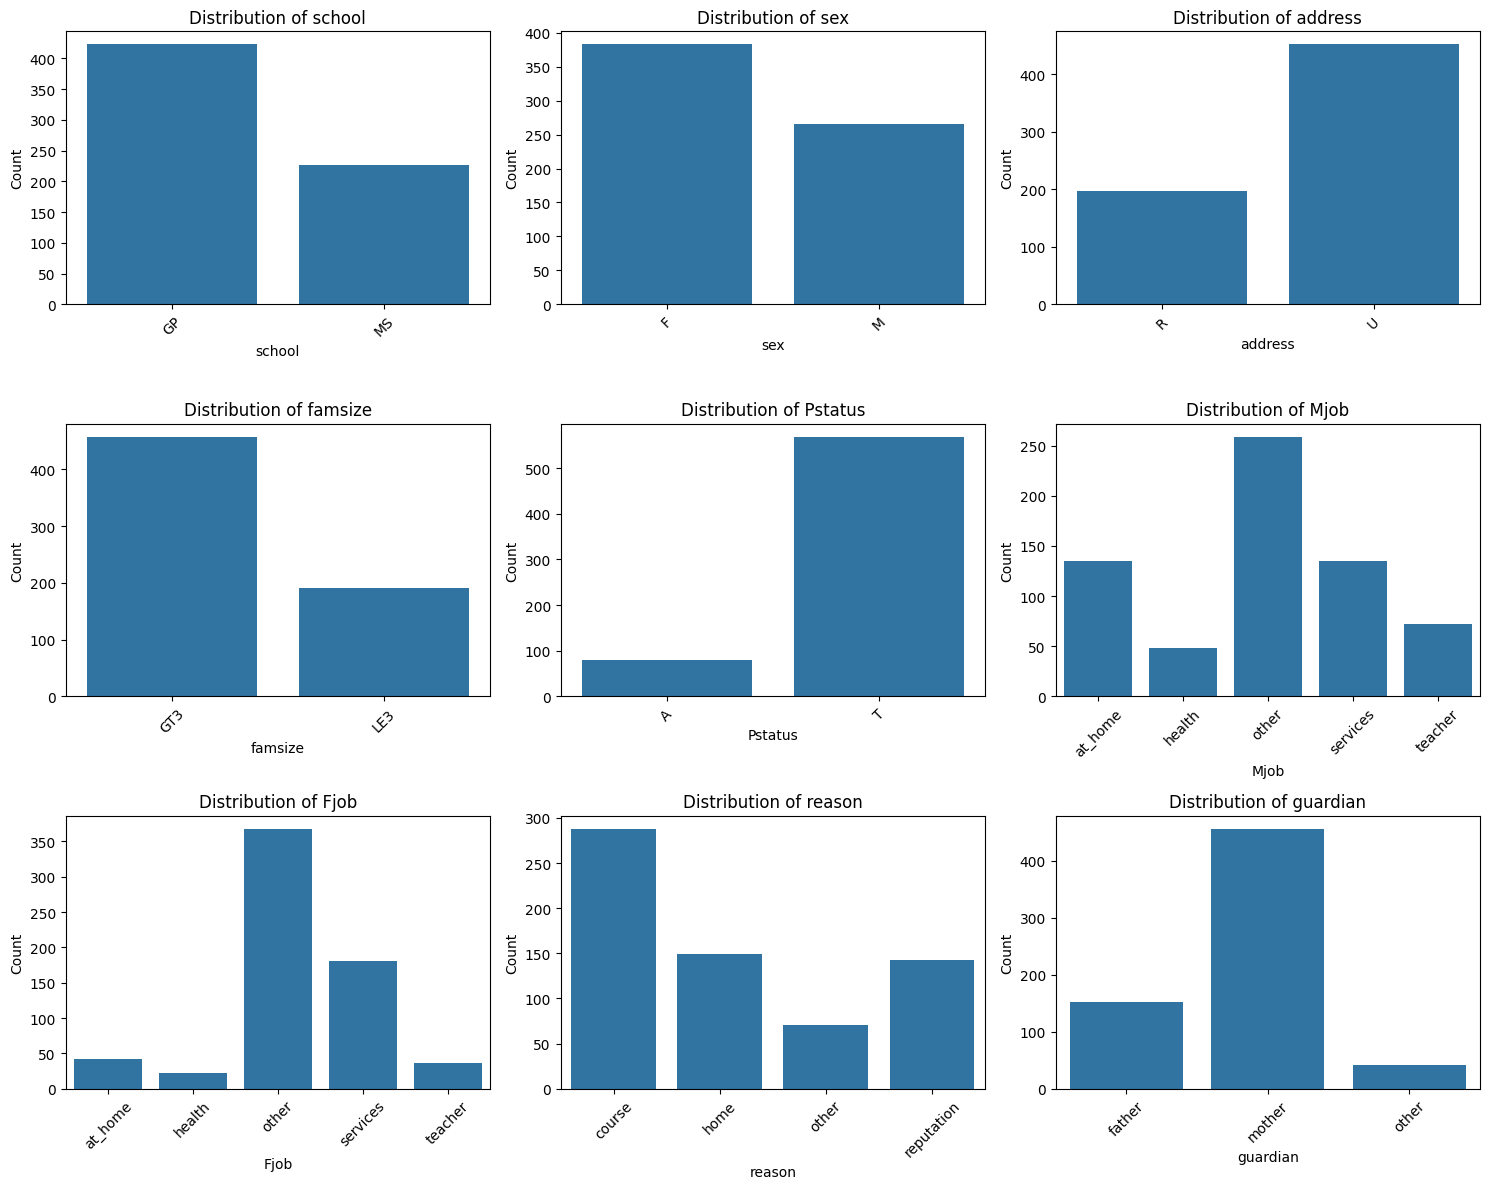

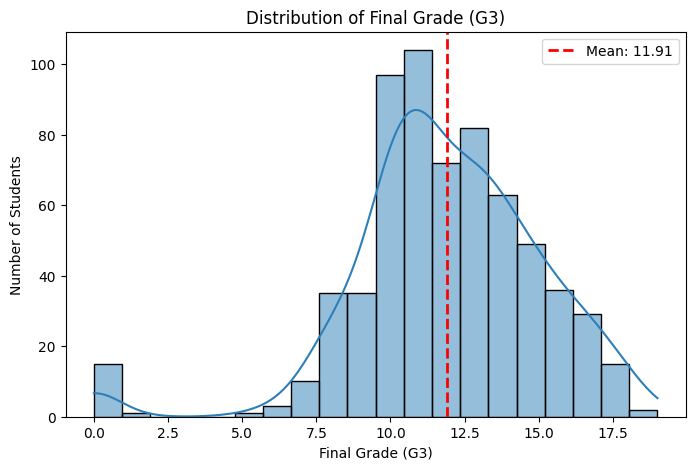

In [29]:
exploratory_data_analysis(portuguese)

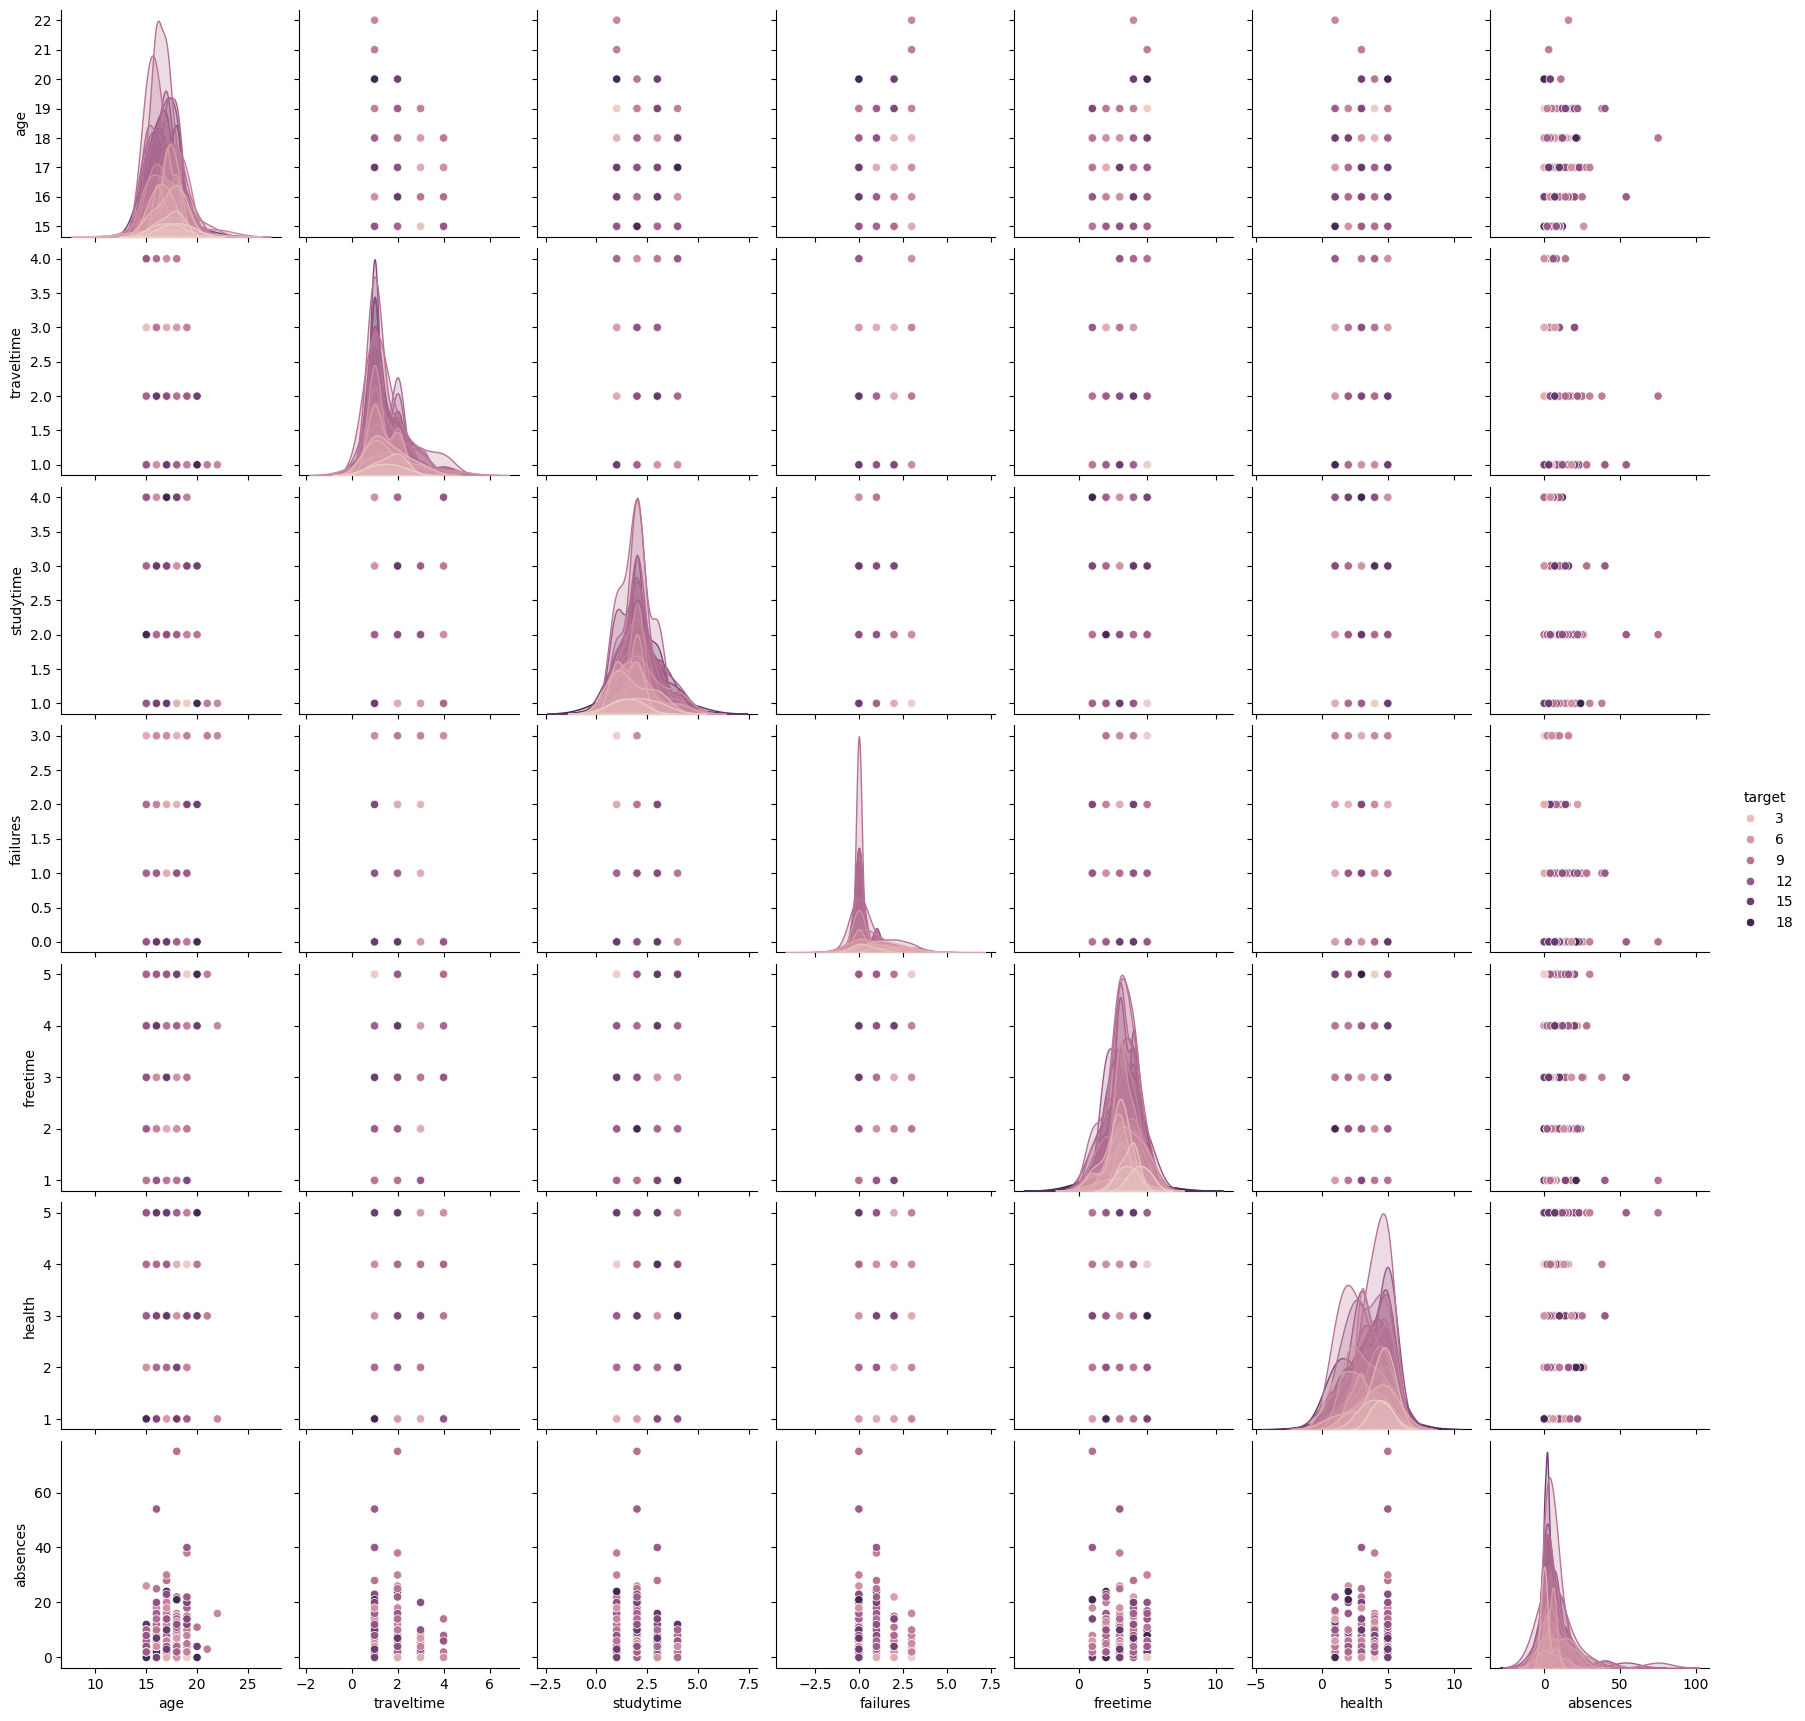

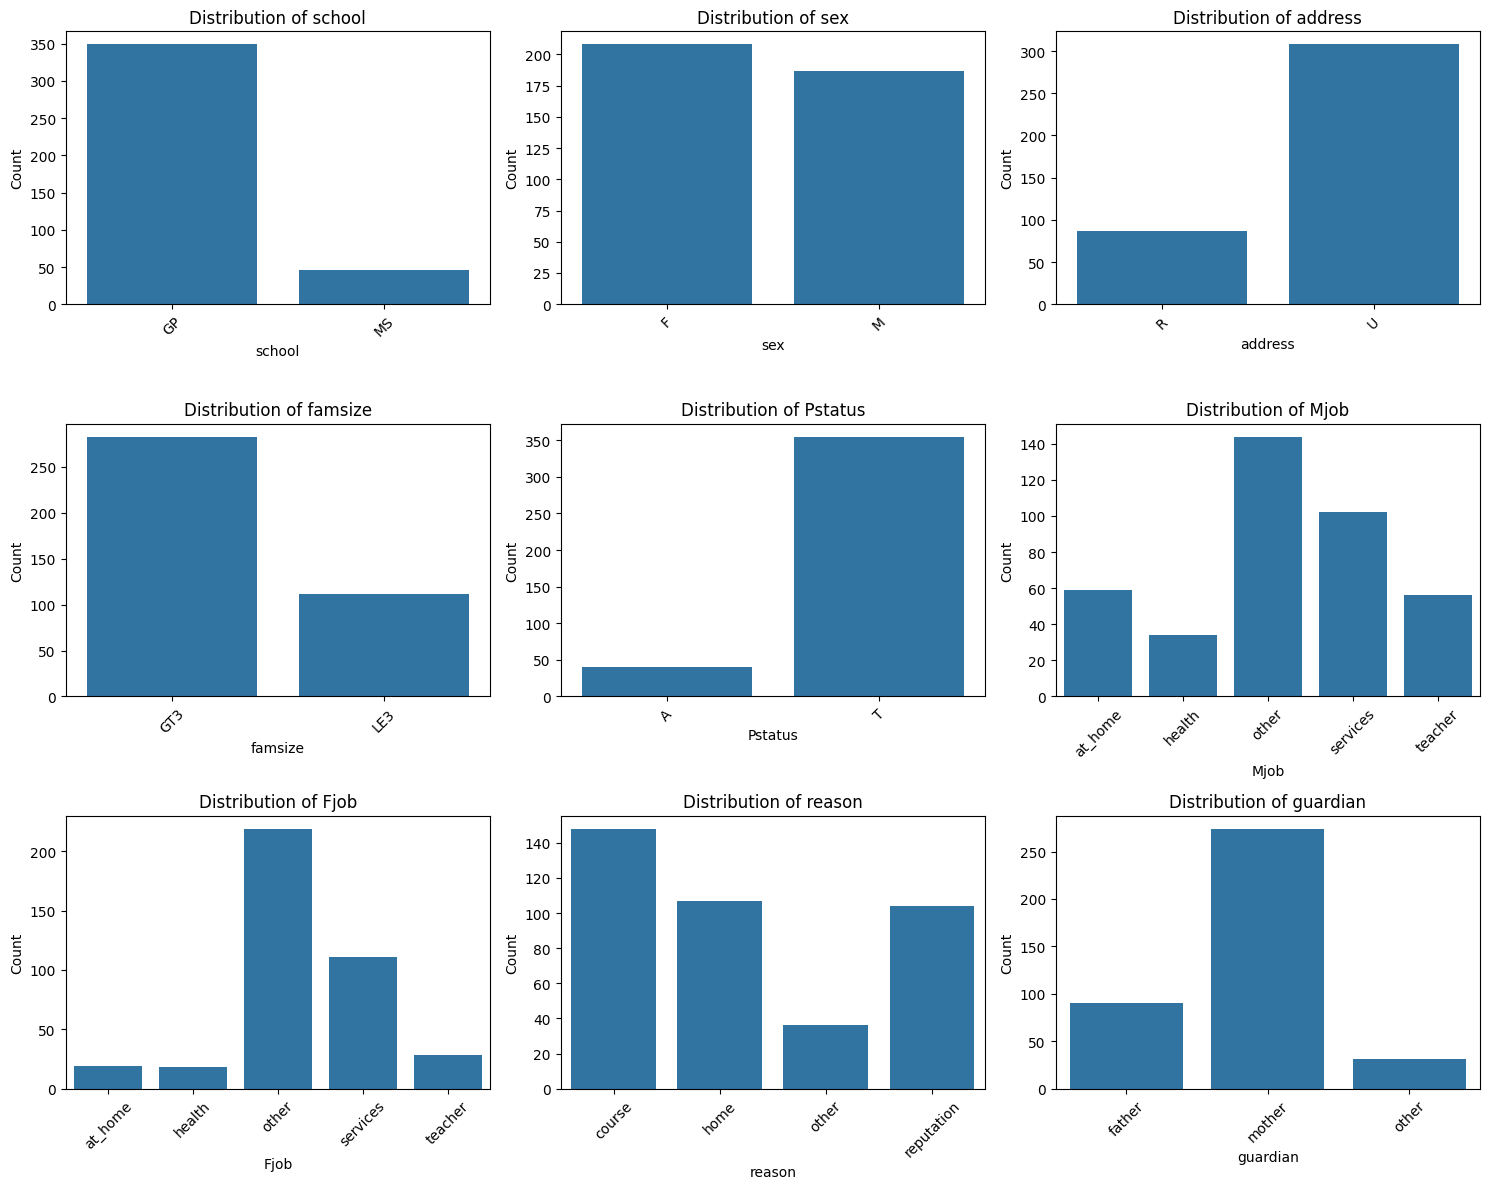

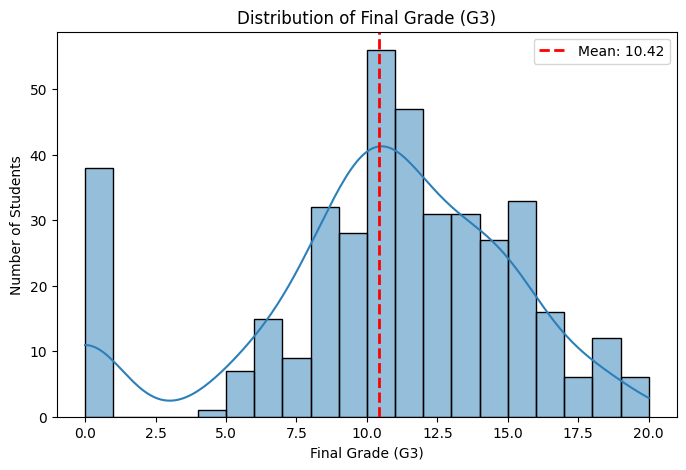

In [30]:
exploratory_data_analysis(math)

In [31]:
def create_dashboard(df: pd.DataFrame) -> alt.Chart:
    df = df.copy()
    # 1. Define the brush selection
    brush = alt.selection_interval()

    sex_color_scale = alt.Scale(domain=['F', 'M'], range=['#ff7f0e', '#1f77b4'])

    base = alt.Chart(df).properties(
        width=300,
        height=250
    )

    # --- TOP LEFT: Context & Focus ---

    # 1A. The Minimap (Used ONLY for drawing the filter box)
    minimap = alt.Chart(df).mark_circle(size=15, opacity=0.6).encode(
        x=alt.X('G3:Q', axis=None), # Hide axes to save space
        y=alt.Y('absences:Q', axis=None),
        color=alt.condition(brush, alt.value('#2c7fb8'), alt.value('lightgray'))
    ).add_params(
        brush
    ).properties(
        width=300,
        height=50, # Keep it short!
        title="Navigator: Drag here to Filter & Zoom"
    )

    # 1B. The Main Scatter (Interactive, pans, zooms, AND is filtered by the minimap)
    main_scatter = alt.Chart(df).mark_circle().transform_filter(
        brush
    ).encode(
        # We remove the fixed scale domains here so it can auto-zoom to your selection!
        x=alt.X('G3:Q', title='Final Grade'), 
        y=alt.Y('absences:Q', title='Absences'), 
        size=alt.Size('count():Q', title='Number of Students', scale=alt.Scale(range=[20, 600])), 
        color=alt.value('#2c7fb8'), # Solid color, no gray-out needed since it's filtered
        tooltip=['G3', 'absences', 'count()']
    ).properties(
        width=300,
        height=180 # Slightly shorter to accommodate the minimap above it
    ).interactive() # Normal scrolling and panning works perfectly here!

    # Combine them vertically into a single unit
    scatter_combo = minimap & main_scatter

    study_labels= "datum.value == 1 ? '<2 hours' : datum.value == 2 ? '2-5 hours' : datum.value == 3 ? '5-10 hours' : '>10 hours'"

    # --- TOP RIGHT: Study Time vs Final Grade ---
    scatter2 = base.mark_boxplot(extent='min-max').transform_filter(
        brush
    ).encode(
        x=alt.X('studytime:O', title='Study Time', scale=alt.Scale(domain=[1, 2, 3, 4]), axis=alt.Axis(labelExpr=study_labels, labelAngle=-45)),
        y=alt.Y('G3:Q', title='Final Grade', scale=alt.Scale(domain=[0, 20])),
        color=alt.Color('sex:N', title='Sex', scale=sex_color_scale), # Applied flipped colors
        xOffset=alt.XOffset('sex:N', sort=['F', 'M']) # Ensure offset order remains constant
    ).properties(
        title="Grade Distribution by Study Time"
    )

    # --- BOTTOM LEFT: Heatmap for Parental Education ---
    edu_labels = "datum.value == 0 ? 'None' : datum.value == 1 ? 'Primary' : datum.value == 2 ? '5th-9th' : datum.value == 3 ? 'Secondary' : 'Higher'"

    heatmap_base = base.transform_filter(
        brush
    ).transform_aggregate(
        count='count()',
        groupby=['Medu', 'Fedu']
    ).encode(
        # Locked domain 0-4
        x=alt.X('Medu:O', title='Mother Education', scale=alt.Scale(domain=[0, 1, 2, 3, 4]), axis=alt.Axis(labelExpr=edu_labels, labelAngle=-45)),
        # Locked domain 4-0
        y=alt.Y('Fedu:O', title='Father Education', scale=alt.Scale(domain=[4, 3, 2, 1, 0]), axis=alt.Axis(labelExpr=edu_labels))
    )

    heatmap_rect = heatmap_base.mark_rect().encode(
        color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'), title='Count')
    )

    heatmap_text = heatmap_base.mark_text().encode(
        text='count:Q',
        color=alt.condition(
            alt.datum.count > 50,  
            alt.value('black'),
            alt.value('white')
        )
    )

    heatmap = (heatmap_rect + heatmap_text).properties(
        title="Parental Education Heatmap"
    )


    # --- BOTTOM RIGHT: Social Life Averages ---
    social_plot = alt.Chart(df).transform_filter(
        brush
    ).transform_fold(
        ['Dalc', 'Walc', 'freetime', 'goout'],
        as_=['Metric', 'Score']
    ).mark_bar().encode(
        # Locked the Metric domain so columns don't vanish if unselected
        x=alt.X('Metric:N', title='Social Metric', scale=alt.Scale(domain=['Dalc', 'Walc', 'freetime', 'goout']), axis=alt.Axis(labelAngle=0)),
        y=alt.Y('mean(Score):Q', title='Average Score (1=Low, 5=High)', scale=alt.Scale(domain=[0, 5])),
        color=alt.Color('sex:N', title='Sex', scale=sex_color_scale, legend=None), # Applied flipped colors
        xOffset=alt.XOffset('sex:N', scale=alt.Scale(domain=['F', 'M'])),
        tooltip=['Metric:N', 'sex:N', 'mean(Score):Q']
    ).properties(
        width=300,
        height=250,
        title='Social Life Averages'
    )

    # Use a 2-column grid layout
    dashboard = alt.concat(
        scatter_combo, scatter2, heatmap, social_plot, 
        columns=2
    )
    return dashboard

## Training and evaluating models for Portuguese and Math datasets

In [32]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [33]:
# drop unnecessary columns for modeling
# we want to predict G3, so we can drop G1 and G2 as they are intermediate grades
for df in data_frames:
    df.drop(columns=["id", "G2"], inplace=True, errors="ignore")

# categorical columns to one-hot encode
categorical = ["Mjob", "Fjob", "guardian", "reason"]


In [34]:
portuguese.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G3
0,GP,F,15.0,U,GT3,A,4.0,3.0,services,services,...,no,4.0,3,2.0,1.0,1.0,1.0,0.0,15,15
1,GP,M,16.0,R,GT3,T,4.0,2.0,teacher,services,...,yes,4.0,3,3.0,3.0,4.0,3.0,8.0,10,11
2,MS,F,16.0,R,LE3,T,1.0,2.0,at_home,other,...,no,4.0,4,5.0,1.0,3.0,3.0,0.0,8,9
3,GP,F,17.0,U,GT3,T,2.0,1.0,services,other,...,no,4.0,3,5.0,2.0,4.0,4.0,4.0,12,16
4,GP,F,17.0,U,GT3,T,2.0,3.0,other,other,...,yes,4.0,2,1.0,1.0,1.0,3.0,2.0,11,14


In [35]:
ordinal = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
]

binary_maps = {
    "school": {"GP": 1, "MS": 0},
    "sex": {"F": 1, "M": 0},
    "address": {"U": 1, "R": 0},
    "famsize": {"GT3": 1, "LE3": 0},
    "Pstatus": {"T": 1, "A": 0},
    "schoolsup": {"yes": 1, "no": 0},
    "famsup": {"yes": 1, "no": 0},
    "paid": {"yes": 1, "no": 0},
    "activities": {"yes": 1, "no": 0},
    "nursery": {"yes": 1, "no": 0},
    "higher": {"yes": 1, "no": 0},
    "internet": {"yes": 1, "no": 0},
    "romantic": {"yes": 1, "no": 0},
}

categorical_nominal = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

numeric = [
    "age",
    "absences"
]

for df in data_frames:
    for col, mapping in binary_maps.items():
        df[col] = df[col].map(mapping).astype("float32")
    for column in ordinal:
        df[column] = pd.to_numeric(df[column], errors="coerce").astype("float64")
    for column in categorical_nominal:
        df[column] = df[column].astype("category")
    for column in numeric:
        df[column] = df[column].astype("float64")


In [36]:
def add_features(df):
    df = df.copy()
    df["parent_edu"]     = (df["Medu"] + df["Fedu"]) / 2           # combined parental education
    df["alc_total"]      = (df["Dalc"] * 5 + df["Walc"] * 2) / 7   # weekday-weighted alcohol index
    df["study_vs_goout"] = df["studytime"] - df["goout"]            # net academic effort signal
    return df

portuguese = add_features(portuguese)
math       = add_features(math)

### Model 1: XGBoost Regressor

As a first model, we will use the XGBoost Regressor, which is a powerful gradient boosting algorithm that has shown excellent performance in various regression tasks. We will train this model on both the Portuguese and Math datasets to predict the final grades of the students.

In [40]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__n_estimators":     [500, 1000],
    "model__max_depth":        [3, 4, 5],
    "model__learning_rate":    [0.001, 0.01, 0.05],
    "model__subsample":        [0.7, 0.9],
    "model__colsample_bytree": [0.7, 1.0],
    "model__min_child_weight": [1, 3],
}

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["float64", "float32", "int64"]).columns.tolist()
    nominal_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    return ColumnTransformer(
        transformers=[
            ("cat", nominal_transformer, categorical_nominal),
            ("num", numeric_transformer, numeric_cols),
        ],
        remainder="drop"
    )

def train_xgboost_model(df, label="Dataset"):
    df = df.copy()

    X = df.drop(columns=["G3"])
    y = df["G3"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    preprocessor = build_preprocessor(X_train)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=42, eval_metric="rmse")),
    ])

    search = GridSearchCV(pipeline, param_grid, scoring="r2", cv=cv, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)

    best = search.best_estimator_
    predictions = best.predict(X_test)

    r2  = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    cv_scores = cross_val_score(best, X, y, cv=cv, scoring="r2")

    print(f"=== {label} ===")
    print(f"Best params:   {search.best_params_}")
    print(f"Hold-out R²:   {r2:.4f}   MSE: {mse:.4f}")
    print(f"CV R²:         {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    return best, build_preprocessor(X)   # return preprocessor for reuse


In [41]:
# compare, without G1 
xgb_port, preprocessor_port = train_xgboost_model(portuguese[portuguese["G3"] > 0].drop(columns=["G1"]), "Portuguese")

# with G1
xgb_port_g1, preprocessor_port_g1 = train_xgboost_model(portuguese[portuguese["G3"] > 0], "Portuguese with G1")

=== Portuguese ===
Best params:   {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__subsample': 0.9}
Hold-out R²:   0.3449   MSE: 4.7132
CV R²:         0.3476 ± 0.0285
=== Portuguese with G1 ===
Best params:   {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 500, 'model__subsample': 0.9}
Hold-out R²:   0.8089   MSE: 1.3747
CV R²:         0.7685 ± 0.0314


In [42]:
# without  G1
xgb_math, preprocessor_math = train_xgboost_model(math[math["G3"] > 0].drop(columns=["G1"]), "Math")

# with G1
xgb_math_g1, preprocessor_math_g1 = train_xgboost_model(math[math["G3"] > 0], "Math with G1")

=== Math ===
Best params:   {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 500, 'model__subsample': 0.7}
Hold-out R²:   0.2292   MSE: 6.5828
CV R²:         0.1480 ± 0.0854
=== Math with G1 ===
Best params:   {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 500, 'model__subsample': 0.7}
Hold-out R²:   0.7740   MSE: 1.9302
CV R²:         0.7886 ± 0.0448
